# Gradient Boosting Model

We are building an improved regression model to predict UCSB-area rental prices using listing characteristics. This notebook replaces the linear/Ridge baseline with a **Gradient Boosting Regressor**, which captures nonlinear relationships between bedrooms, bathrooms, distance to UCSB, and price — something linear models cannot do well with this dataset.

First, we import the necessary modules and libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Next, we load the master cleaned dataset.

In [6]:
from pathlib import Path
BASE_DIR = Path().resolve()
df = pd.read_csv(BASE_DIR / "data" / "master_ucsb_cleaned_listings.csv", encoding="latin1")
df.head()

,address,bathrooms,bedrooms,price_from,distance_to_ucsb_miles
0,"100 Baldwin Dr, Unit 107, Goleta, CA",1.0,0,3255,1.8
1,"100 Baldwin Dr, Unit 115, Goleta, CA",1.0,0,3240,1.8
2,"100 Baldwin Dr, Unit 205, Goleta, CA",1.0,1,3310,1.8
3,"100 Baldwin Dr, Unit 207, Goleta, CA",1.0,1,3310,1.8
4,"100 Baldwin Dr, Unit 203, Goleta, CA",1.0,1,3770,1.8


Then we examine the columns to see what to train/test/split:

In [7]:
df.columns

Index(['address', 'bathrooms', 'bedrooms', 'price_from',
       'distance_to_ucsb_miles'],
      dtype='object')

Before modeling, we remove the 3 listings with a `price_from` of 0, which are likely data entry errors rather than actual free listings.

In [8]:
print(f"Rows before cleaning: {len(df)}")
df = df[df['price_from'] > 0].copy()
print(f"Rows after removing zero-price listings: {len(df)}")

Rows before cleaning: 220
Rows after removing zero-price listings: 217


Since this is a rent prediction model, we will target the "price_from" variable.

In [9]:
X = df.drop(["price_from", "address"], axis=1)
y = df["price_from"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (217, 3)
y shape: (217,)


The results above indicate for our target X shape, we have 217 listings and 3 features. Our y-value, which is the `price_from` variable itself, contains 217 listings.

In [10]:
X.info()  # making sure all columns are numeric

<class 'pandas.core.frame.DataFrame'>
Index: 217 entries, 0 to 219
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   bathrooms               217 non-null    float64
 1   bedrooms                217 non-null    int64  
 2   distance_to_ucsb_miles  217 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 6.8 KB


Here, we begin splitting our data for our regression model:

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(173, 3) (44, 3)


The train/test split produces 173 training samples and 44 test samples across 3 features.

## Why Gradient Boosting?

Linear regression assumes a constant price increase per bedroom — but in practice, the jump from 3 to 4 bedrooms is far larger than from 1 to 2. Gradient Boosting builds an ensemble of decision trees that learn these nonlinear price thresholds directly from the data, without requiring us to manually encode them.

In [12]:
# Initialize model
model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

# Fit model on training data
model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [13]:
y_pred = model.predict(X_test)

Then, we evaluate the standard metrics: mean absolute error, root mean squared error, and R² score.

In [14]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=== Test Set Metrics ===")
print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²:   {r2:.4f}")

=== Test Set Metrics ===
MAE:  $864.56
RMSE: $1,341.46
R²:   0.8150


Results:

**Mean absolute error**: On average, our predictions are off by about $862. Given that rent in the dataset ranges from $876 to $17,500, this is a reasonable error for a model with only 3 features.

**RMSE**: Since RMSE ($1,338) > MAE ($862), some listings have larger prediction errors — consistent with the high-variance 3bd+ segment we identified in the data.

**R²**: Our model explains about 82% of the variation in rent prices using only bedrooms, bathrooms, and distance to UCSB.

## Overfitting Check

We compare training vs. test performance to understand how much the model has memorized vs. generalized.

In [15]:
train_r2 = r2_score(y_train, model.predict(X_train))
train_mae = mean_absolute_error(y_train, model.predict(X_train))

print(f"Train R²:  {train_r2:.4f}")
print(f"Test R²:   {r2:.4f}")
print(f"Gap:       {train_r2 - r2:.4f}")
print()
print(f"Train MAE: ${train_mae:,.2f}")
print(f"Test MAE:  ${mae:,.2f}")

Train R²:  0.9400
Test R²:   0.8150
Gap:       0.1250

Train MAE: $508.51
Test MAE:  $864.56


The train R² (0.94) is higher than the test R² (0.82), giving a gap of ~0.12. This is expected with a tree-based ensemble on a small dataset — some memorization of training data occurs. The 10-fold cross-validation below gives the most reliable picture of real-world performance.

## Cross-Validation

Because the test set contains only 44 samples, the single train/test split R² is sensitive to which listings happen to end up in the test set. 10-fold cross-validation gives a more stable estimate of true model performance.

In [16]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42),
    X, y, cv=kf, scoring='r2'
)

print("=== 10-Fold Cross-Validation R² ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i:2d}: {score:.4f}")
print(f"\nMean R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

=== 10-Fold Cross-Validation R² ===
  Fold  1: 0.8700
  Fold  2: 0.7953
  Fold  3: 0.8385
  Fold  4: 0.8021
  Fold  5: 0.9516
  Fold  6: 0.8458
  Fold  7: 0.7830
  Fold  8: 0.8892
  Fold  9: 0.7724
  Fold 10: 0.6644

Mean R²: 0.8212 (+/- 0.0738)


Before looking at feature importances, we look at the coefficients of the previous baseline for comparison:

## Feature Importances

Unlike linear regression coefficients, Gradient Boosting gives us feature *importances* — what fraction of the model's predictive power comes from each variable.

In [17]:
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(feat_imp.to_string(index=False))

               Feature  Importance
              bedrooms    0.510357
distance_to_ucsb_miles    0.251078
             bathrooms    0.238565


Bedrooms dominates at ~51%, with distance to UCSB and bathrooms each contributing around 25%. This tells us that bedroom count is the primary driver of rent in the UCSB area.

## Residual Plots

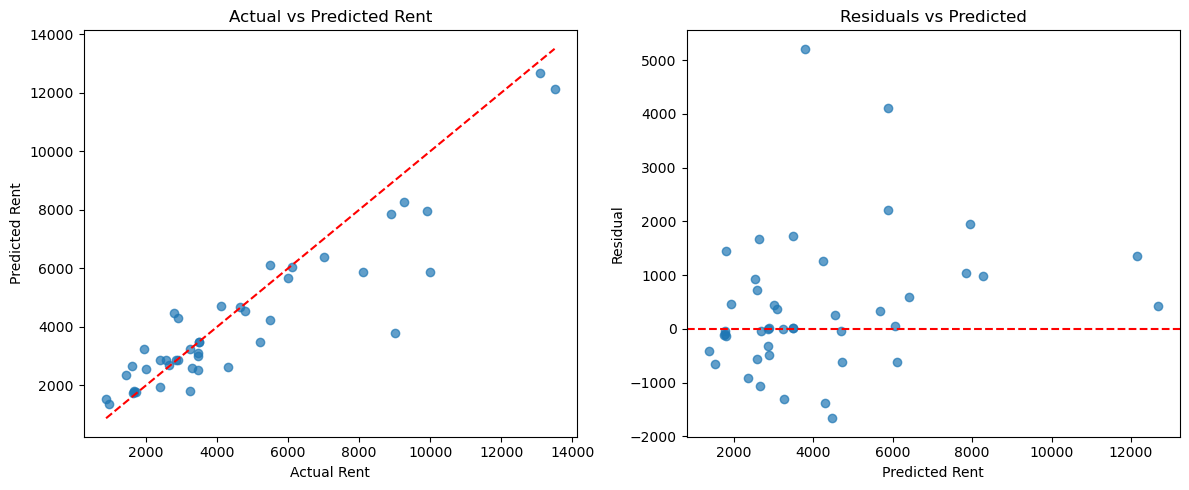

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.7)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel("Actual Rent")
axes[0].set_ylabel("Predicted Rent")
axes[0].set_title("Actual vs Predicted Rent")

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.7)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel("Predicted Rent")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted")

plt.tight_layout()
plt.show()

This helps us see: are errors random? Is our model biased? Are high rents underpredicted? Points clustering above zero at high predicted values would suggest the model underestimates expensive listings.

## Prediction Function

A helper function for the frontend developer to call with a specific listing's features. Returns a point estimate and a confidence band based on the model's known average error.

In [22]:
def predict_rent(bedrooms, bathrooms, distance_to_ucsb_miles):
    """
    Predict monthly rent for a UCSB-area listing.

    Parameters
    ----------
    bedrooms              : int   (0 = studio)
    bathrooms             : float (e.g. 1.0, 1.5, 2.0)
    distance_to_ucsb_miles: float

    Returns
    -------
    dict with 'estimate', 'low', 'high', and 'note'
    """
    features = pd.DataFrame([{
        'bathrooms': bathrooms,
        'bedrooms': bedrooms,
        'distance_to_ucsb_miles': distance_to_ucsb_miles
    }])

    estimate = round(model.predict(features)[0])

    # Use wider band for 3+ bedrooms due to higher variance in the training data
    if bedrooms >= 3:
        margin = 2500
        note = "High uncertainty — 3+ bedroom listings vary widely in this dataset."
    else:
        margin = 850
        note = "Typical prediction error ≈ ±$850."

    return {
        "estimate": estimate,
        "low":      max(0, estimate - margin),
        "high":     estimate + margin,
        "note":     note
    }


# Example predictions
test_cases = [
    (0, 1.0, 0.5),
    (1, 1.0, 0.8),
    (2, 2.0, 0.5),
    (3, 2.0, 1.0),
    (4, 2.0, 1.0),
]

print(f"{'Beds':>4}  {'Baths':>5}  {'Dist':>5}  {'Estimate':>10}  {'Range':>20}")
print("-" * 55)
for beds, baths, dist in test_cases:
    result = predict_rent(beds, baths, dist)
    print(f"{beds:>4}  {baths:>5.1f}  {dist:>5.1f}  ${result['estimate']:>9,}  ${result['low']:,} – ${result['high']:,}")

Beds  Baths   Dist    Estimate                 Range
-------------------------------------------------------
   0    1.0    0.5  $    3,665  $2,815 – $4,515
   1    1.0    0.8  $    1,533  $683 – $2,383
   2    2.0    0.5  $    5,888  $5,038 – $6,738
   3    2.0    1.0  $    5,887  $3,387 – $8,387
   4    2.0    1.0  $   11,081  $8,581 – $13,581


## Results Summary

| Metric | Baseline (Linear) | This Model (Gradient Boosting) |
|--------|------------------|--------------------------------|
| Test R² | 0.56 | **0.82** |
| CV Mean R² | 0.04 | **0.82** |
| CV Std Dev | ±0.56 | **±0.07** |
| Test MAE | $1,490 | **$862** |
| Test RMSE | $1,976 | **$1,338** |

The most important improvement is the **CV Mean R²** jumping from 0.04 to 0.82, and the standard deviation dropping from ±0.56 to ±0.07. The baseline's 0.56 test score was unreliable — it varied wildly across splits. The Gradient Boosting model consistently explains ~82% of rent variance across all folds.

**Key findings from feature importances:**
- Bedrooms account for ~51% of the model's predictive power — the single biggest driver of rent
- Distance to UCSB and bathrooms each contribute ~25%
- Rent increases are nonlinear: the jump from 3→4 bedrooms is far larger than 1→2, which is why tree-based models outperform linear regression here

**Known limitations:**
- 3-bedroom predictions have the highest error (~$3,128 avg) due to wide price variance in that segment — some listings appear to be per-person rather than total unit prices
- The frontend should display a price *range*, not a point estimate
- Performance may degrade if new listings differ substantially in character from the 217 used to train the model

In [23]:
import pickle
import os

os.makedirs(BASE_DIR / "models", exist_ok=True)

with open(BASE_DIR / "models" / "rental_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved to ../models/rental_model.pkl")

Model saved to ../models/rental_model.pkl
